# DetaNet Inference Notebook

Run this after the services are up and a dataset is loaded.

Prereqs:
- `docker compose up --build`
- Build Parquet shards and load the DB (see `README.md`).


In [1]:
import json
import os
from urllib.parse import urlencode
from urllib.request import Request, urlopen

BASE_URL = os.getenv('INFERENCE_BASE_URL', 'http://localhost:8000')
DATASET = os.getenv('INFERENCE_DATASET', 'ext_val')

def get_json(path, params=None):
    url = BASE_URL + path
    if params:
        url += '?' + urlencode(params)
    with urlopen(url) as resp:
        return json.loads(resp.read().decode('utf-8'))

def post_json(path, payload):
    url = BASE_URL + path
    data = json.dumps(payload).encode('utf-8')
    req = Request(url, data=data, headers={'Content-Type': 'application/json'})
    with urlopen(req) as resp:
        return json.loads(resp.read().decode('utf-8'))


In [2]:
get_json('/healthz')


{'status': 'ok'}

In [3]:
datasets = get_json('/datasets')
datasets


{'datasets': [{'name': 'ext_val', 'description': None, 'source_uri': None}]}

In [4]:
datapoints = get_json('/datapoints', params={'dataset': DATASET, 'limit': 1})['datapoints']
datapoints[0]


{'dataset': 'ext_val',
 'molecule_id': 1,
 'smiles': 'C1=CC=NC(=C1)C#N',
 'n_atoms': 12,
 'environment': None}

In [5]:
dp = get_json('/datapoints/{}/{}'.format(DATASET, datapoints[0]['molecule_id']), params={'include_geometry': 'true'})
payload = {'pos': dp['pos'], 'z': dp['z']}
{'pos_len': len(payload['pos']), 'z_len': len(payload['z'])}


{'pos_len': 12, 'z_len': 12}

In [6]:
vib = post_json('/predict/vib', payload)
{'freq_len': len(vib['freq']), 'ir_len': len(vib['ir_intensity']), 'raman_len': len(vib['raman_activity'])}


{'freq_len': 30, 'ir_len': 30, 'raman_len': 30}

In [7]:
raman = post_json('/predict/raman', payload)
{'x_len': len(raman['x']), 'y_len': len(raman['y']), 'png_b64_len': len(raman['png_base64'])}


{'x_len': 3501, 'y_len': 3501, 'png_b64_len': 46620}

In [9]:
uv = post_json('/predict/uv', payload)
{'uv_len': len(uv['uv'])}


{'uv_len': 240}

In [10]:
nmr = post_json('/predict/nmr', payload)
{'sc_len': len(nmr['sc']), 'sh_len': len(nmr['sh']), 'message': nmr.get('message')}


{'sc_len': 6,
 'sh_len': 4,
 'message': 'Provide indexc/indexh to /predict/nmr/aggregate for environment aggregation.'}

In [11]:
agg_payload = {
    'sc': nmr['sc'],
    'sh': nmr['sh'],
    'indexc': list(range(len(nmr['sc']))),
    'indexh': list(range(len(nmr['sh']))),
}
agg = post_json('/predict/nmr/aggregate', agg_payload)
{
    'shiftc_len': len(agg['shiftc']),
    'intc_len': len(agg['intc']),
    'shifth_len': len(agg['shifth']),
    'inth_len': len(agg['inth']),
}


{'shiftc_len': 6, 'intc_len': 6, 'shifth_len': 4, 'inth_len': 4}

In [12]:
inline_payload = {'pos': [[0, 0, 0], [0, 0, 1]], 'z': [6, 1]}
charge = post_json('/predict/charge', inline_payload)
uv_inline = post_json('/predict/uv', inline_payload)
{'charge_len': len(charge['charge']), 'uv_len': len(uv_inline['uv'])}


{'charge_len': 2, 'uv_len': 240}

In [13]:
!pip install matplotlib

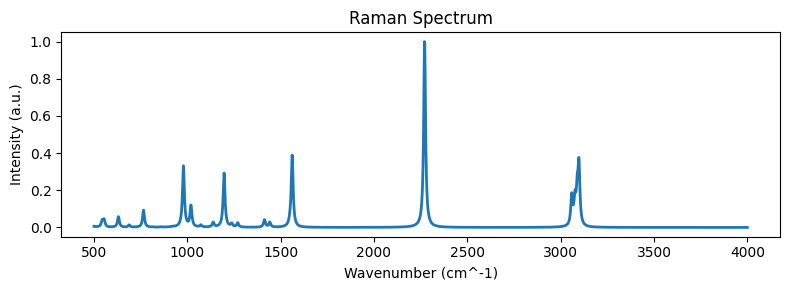

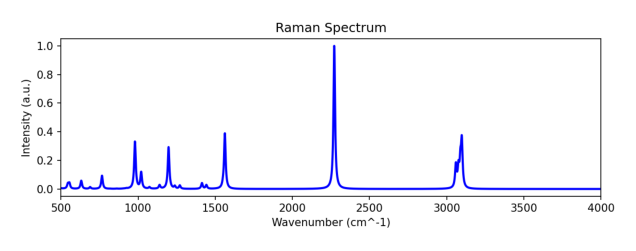

In [14]:
raman = post_json('/predict/raman', payload)

# Plot spectrum from x/y
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(raman["x"], raman["y"], lw=2)
plt.xlabel("Wavenumber (cm^-1)")
plt.ylabel("Intensity (a.u.)")
plt.title("Raman Spectrum")
plt.tight_layout()
plt.show()

#And to render the PNG coming back from the API:

import base64
import io
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

png_bytes = base64.b64decode(raman["png_base64"])
img = mpimg.imread(io.BytesIO(png_bytes), format="png")
plt.figure(figsize=(8, 3))
plt.imshow(img)
plt.axis("off")
plt.show()

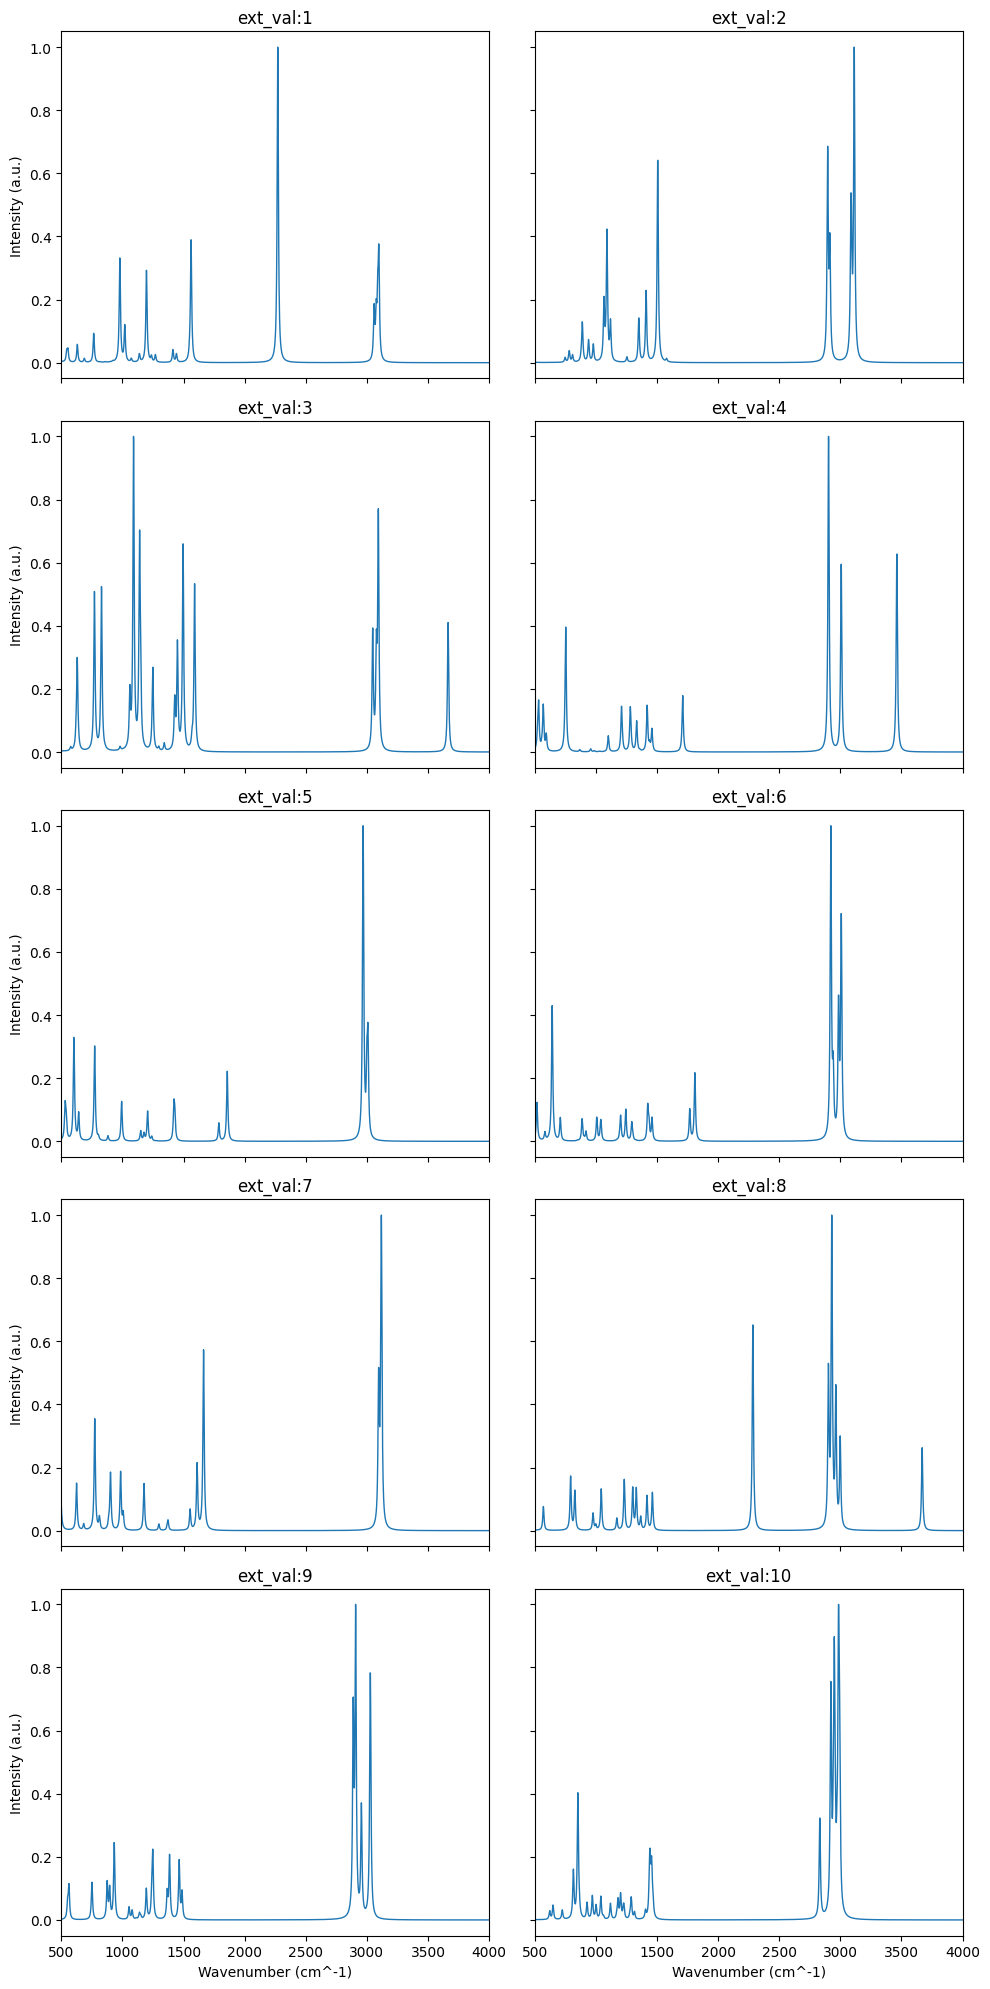

In [15]:
# Plot 10 Raman spectra from dataset-backed payloads
datapoints_10 = get_json('/datapoints', params={'dataset': DATASET, 'limit': 10})['datapoints']
if not datapoints_10:
    raise RuntimeError(f"No datapoints found for dataset '{DATASET}'")

payloads = []
for dp_item in datapoints_10:
    dp_full = get_json('/datapoints/{}/{}'.format(DATASET, dp_item['molecule_id']), params={'include_geometry': 'true'})
    payloads.append({'pos': dp_full['pos'], 'z': dp_full['z']})

ramans = [post_json('/predict/raman', p) for p in payloads]

import matplotlib.pyplot as plt

cols = 2
rows = (len(datapoints_10) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, dp_item, raman in zip(axes, datapoints_10, ramans):
    ax.plot(raman['x'], raman['y'], lw=1)
    ax.set_title(f"{DATASET}:{dp_item['molecule_id']}")
    ax.set_xlim(500, 4000)

for ax in axes[len(datapoints_10):]:
    ax.axis('off')

for ax in axes[-cols:]:
    ax.set_xlabel('Wavenumber (cm^-1)')
for ax in axes[::cols]:
    ax.set_ylabel('Intensity (a.u.)')

fig.tight_layout()
plt.show()